In [ ]:
# Import Libraries
import os
import pandas as pd
import numpy as np
import xgboost as xgb
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, f1_score,
    precision_score, recall_score,
    roc_auc_score, average_precision_score,
    confusion_matrix, ConfusionMatrixDisplay,
    classification_report
)
from IPython.display import display
from google.colab import drive
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_sample_weight

In [ ]:
# Enable and Confirm GPU Support
# XGboost must run a "dummy test" to confirm
try:
    xgb.train(
        {"device": "cuda"},
        xgb.DMatrix([[0]], label=[0]),
        num_boost_round=1
    )
    DEVICE = "cuda"
    print("GPU confirmed. XGBoost is using CUDA.")

except Exception as gpu_error:
    try:
        xgb.train(
            {"device": "cpu"},
            xgb.DMatrix([[0]], label=[0]),
            num_boost_round=1
        )
        DEVICE = "cpu"
        print(
            f"GPU support unavailable. [Reason: {gpu_error}]\n"
            f"Model has successfully defaulted to CPU usage instead."
        )

    except Exception as cpu_error:
        DEVICE = None
        print(
            f"GPU and CPU usage are both unavailable.\n"
            f"  GPU Reason: {gpu_error}\n"
            f"  CPU Reason: {cpu_error}\n\n"
            f"Troubleshooting suggestions:\n"
            f"  1. Verify XGBoost is installed correctly  : pip install xgboost\n"
            f"  2. Verify your CUDA drivers are up to date : https://developer.nvidia.com/cuda-downloads\n"
            f"  3. Confirm your Python environment is not corrupted\n"
            f"  4. Try reinstalling XGBoost                : pip install --force-reinstall xgboost"
        )

GPU confirmed. XGBoost is using CUDA.


In [ ]:
# Define file path & Load TRAIN and VALIDATE Datasets
drive.mount('/content/drive', force_remount=True)
df = pd.read_csv('/content/drive/MyDrive/xg-ids/5class/datasets/5class_TRAIN.txt')
df_val = pd.read_csv('/content/drive/MyDrive/xg-ids/5class/datasets/5class_VALIDATE.txt')

Mounted at /content/drive


In [ ]:
feat_imp = {
    'urgent'                     : 1,
    'land'                       : 1,
    'num_outbound_cmds'          : 1,
    'is_host_login'              : 1,
    'su_attempted'               : 1,
    'srv_diff_host_rate'         : 1,
    'srv_serror_rate'            : 2,
    'serror_rate'                : 3,
    'srv_rerror_rate'            : 4,
    'num_shells'                 : 5,
    'dst_host_srv_rerror_rate'   : 6,
    'is_guest_login'             : 7,
    'dst_host_rerror_rate'       : 8,
    'dst_host_srv_diff_host_rate': 9,
    'same_srv_rate'              : 10,
    'rerror_rate'                : 11,
    'dst_host_srv_count'         : 12,
    'dst_host_same_srv_rate'     : 13,
    'protocol_type'              : 14,
    'num_access_files'           : 15,
    'num_compromised'            : 16,
    'num_root'                   : 17,
    'srv_count'                  : 18,
    'dst_host_srv_serror_rate'   : 19,
    'dst_host_count'             : 20,
    'dst_host_same_src_port_rate': 21,
    'hot'                        : 22,
    'num_file_creations'         : 23,
    'logged_in'                  : 24,
    'dst_host_diff_srv_rate'     : 25,
    'flag'                       : 26,
    'src_bytes'                  : 27,
    'root_shell'                 : 28,
    'dst_host_serror_rate'       : 29,
    'dst_bytes'                  : 30,
    'wrong_fragment'             : 31,
    'diff_srv_rate'              : 32,
    'duration'                   : 33,
    'count'                      : 34,
    'service'                    : 35,
    'num_failed_logins'          : 36,
}

# Drop Low-Importance Columns
cols_to_drop = [feat for feat, rank in feat_imp.items() if rank <= 4 ]

if cols_to_drop:
    df.drop(columns=cols_to_drop, inplace=True, errors='ignore')
    df_val.drop(columns=cols_to_drop, inplace=True, errors='ignore')
    print(f"Dropped {len(cols_to_drop)} low-importance column(s): {cols_to_drop}")
    print(f"  Train shape   : {df.shape}")
    print(f"  Validate shape: {df_val.shape}")
else:
    print("No columns to drop.")

# Keep zv_train and zv_val defined so downstream code doesn't break
zv_train = []
zv_val   = []

Dropped 9 low-importance column(s): ['urgent', 'land', 'num_outbound_cmds', 'is_host_login', 'su_attempted', 'srv_diff_host_rate', 'srv_serror_rate', 'serror_rate', 'srv_rerror_rate']
  Train shape   : (39928, 33)
  Validate shape: (12663, 33)


In [ ]:
# XGBOOST CONFIGURATIONS
config = {

    #GLOBAL & GENERAL CONFIGURATIONS
    "verbosity"            : 1,                # 0 (silent), 1 (warning), 2 (info), 3 (debug)
    "booster"              : "gbtree",         # DEFAULT: gbtree --  Options: "gbtree" (Standard Gradient Boosting), "gblinear" (Linear Models), "dart" (Dropout Trees)
    "device"               : DEVICE,           # Options: "cuda", "cpu" - Specified in cell 2
    "validate_parameters"  : True,          # Use with Python. XGBoost validates input parameters and warns if any are unused or unrecognized.
    "disable_default_eval_metric" : False,    # XGBoost supports variety of "eval_metric" options with defaults and customizability.

    # TREE BOOSTER PARAMETERS
    "eta"                  : 0.05,              # DEFAULT: 0.3 - Alias for "learning_rate". Controls step size shrinkage to prevent overfitting.
    "gamma"                : 2,                # DEFAULT: 0 - Minimum loss reduction required to make a split. Higher values = more conservative models.
    "max_depth"            : 8,                # DEFAULT: 6 - Maximum depth of a tree. Increasing may capture more complex patterns BUT may overfit.
    "min_child_weight"     : 5,                # DEFAULT: 1 - [Options: 0,∞] Minimum sum of instance weight (hessian) needed in a child. Higher values prevent overfitting.
                                               # Relevant for U2R and R2L (Low # might cause overfitting)
    "max_delta_step"       : 1,                # DEFAULT: 0 - Maximum delta step allowed. 0 = no constraints. May help with logistic regressionin imbalanced datasets.
    "subsample"           : 0.8,                # DEFAULT: 1 - [Range: 0,1]Randomly subsample dataset prior to growing tree. May prevent overfitting. Occurs once per boosting iteration.
    "sampling_method"      : "uniform",        # DEFAULT: uniform - Options: "uniform" (Random sampling), "gradient_based" (Gradient-based sampling)
    "lambda"               : 3,                # DEFAULT: 1 - [Options: 0,∞] (Alias: reg_lambda) L2 regularization term on weights. Increase = more conservative models.
    "alpha"                : 1,                # DEFAULT: 0 - [Options: 0,∞] (Alias: reg_alpha) L1 regularization term on weights. Increase = more conservative models.
    "tree_method"         : "hist",            # DEFAULT: auto - Options: "auto" (same as "hist"), "exact" (Exact greedy algorithm), "approx" (Approximate algorithm using quantile sketching), "hist" (Histogram-based algorithm)
    "process_type"        : "default",         # DEFAULT: default - Options: "default" (Standard training), "update" (Continue training from existing model)
    "objective"            : "multi:softprob", # Many other options (see documentation), but "multi:softmax" is likely the most promising alternative.
    # "base_score" -- Automatically estimated by XGBoost for multi:softprob — no manual override needed
    "eval_metric" : ["mlogloss", "merror"], # Defaults to "mlogloss" for multi:softprob, but can be overridden with other options. See documentation.
    "seed" : 0, # RNG to ensure reproducibility of results across different runs/environments.
    "enable_categorical" : True, # Avoids using One-Hot Encoding and allows XGBoost to natively handle categorical features.
    "num_class"            : 5,  # Required for multiclass classification with "multi:softprob" objective. Specifies number of classes in the dataset.
    "n_estimators"         : 500,              # DEFAULT: 100 - Number of boosting rounds (trees).
    "early_stopping_rounds": 20,        # DEFAULT: None -- Early stopping if no imporvement (eval metric) for specified rounds.
    # Prototyping
    "prototyping"          : False,
    "prototyping_frac"     : 0.2,              # fraction of data to use when prototyping
    "prototyping_stratified": True,            # ensure all classes are represented
}

In [ ]:
# TRAIN & VALIDATE Dataset: Encode datasets + separate Features and Targets
# Cast categorical feature columns to category dtype for XGBoost native handling
categorical_cols = ['protocol_type', 'service', 'flag']
for col in categorical_cols:
    df[col]     = df[col].astype('category')
    df_val[col] = df_val[col].astype('category')

# Encode target class labels to integers (required by XGBoost)
le = LabelEncoder()
df['class']     = le.fit_transform(df['class'])
df_val['class'] = le.transform(df_val['class'])

# Print class encoding map
class_map = dict(zip(le.classes_, le.transform(le.classes_)))
print("Class encoding map:")
for cls, idx in class_map.items():
    print(f"  {cls} → {idx}")

# Separate features and target
X_train = df.drop(columns=['class'])
y_train = df['class']

X_val   = df_val.drop(columns=['class'])
y_val   = df_val['class']

Class encoding map:
  DoS → 0
  Normal → 1
  Probe → 2
  R2L → 3
  U2R → 4


In [ ]:
# Prototyping Configurations
if config["prototyping"]:
    X_train, _, y_train, _ = train_test_split(
        X_train, y_train,
        train_size=config["prototyping_frac"],
        stratify=y_train if config["prototyping_stratified"] else None,
        random_state=config["seed"]
    )
    X_val, _, y_val, _ = train_test_split(
        X_val, y_val,
        train_size=config["prototyping_frac"],
        stratify=y_val if config["prototyping_stratified"] else None,
        random_state=config["seed"]
    )
    print(f"Prototyping mode: using {len(X_train)} train instances and {len(X_val)} val instances ({config['prototyping_frac']*100:.0f}% of each dataset)")
else:
    print(f"Full training mode: using {len(X_train)} train instances and {len(X_val)} val instances")

Full training mode: using 39928 train instances and 12663 val instances


In [ ]:
model = xgb.XGBClassifier(
    verbosity          = config["verbosity"],
    booster            = config["booster"],
    device             = config["device"],
    validate_parameters= config["validate_parameters"],
    eta                = config["eta"],
    gamma              = config["gamma"],
    max_depth          = config["max_depth"],
    min_child_weight   = config["min_child_weight"],
    max_delta_step     = config["max_delta_step"],
    subsample          = config["subsample"],
    sampling_method    = config["sampling_method"],
    reg_lambda         = config["lambda"],
    reg_alpha          = config["alpha"],
    tree_method        = config["tree_method"],
    process_type       = config["process_type"],
    objective          = config["objective"],
    eval_metric        = config["eval_metric"],
    seed               = config["seed"],
    enable_categorical = config["enable_categorical"],
    num_class          = config["num_class"],
    n_estimators       = config["n_estimators"],
    early_stopping_rounds = config["early_stopping_rounds"],
)

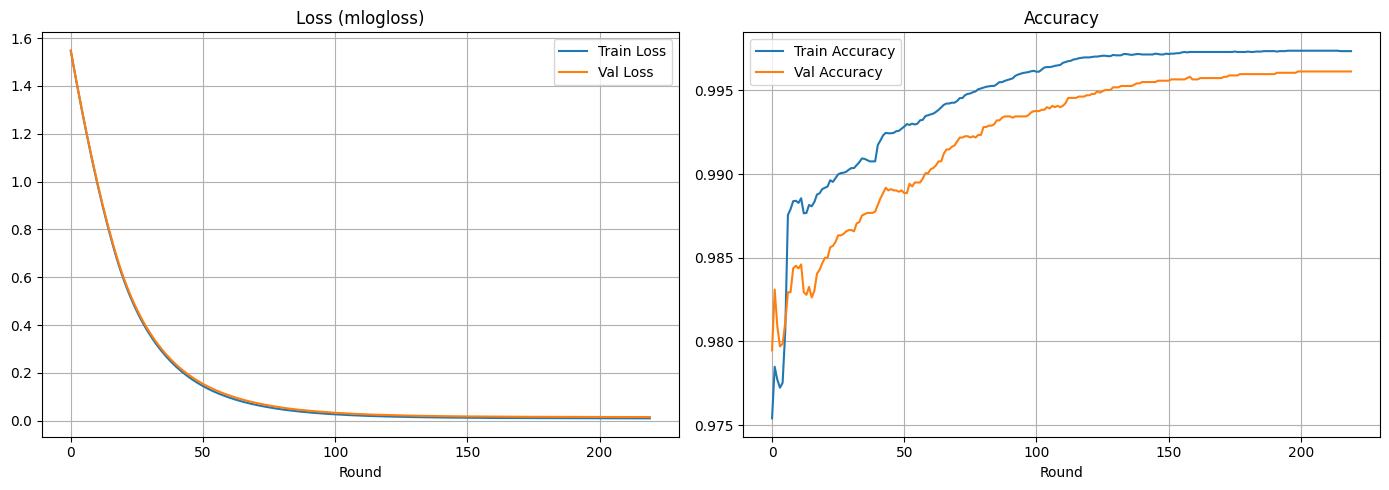

In [13]:
evals_result = {}

model.fit(
    X_train, y_train.to_numpy(),
    sample_weight=compute_sample_weight('balanced', y_train),
    eval_set=[(X_train, y_train.to_numpy()), (X_val, y_val.to_numpy())],
    verbose=False
)

# Plot after training
evals_result = model.evals_result()
train_loss = evals_result["validation_0"]["mlogloss"]
val_loss   = evals_result["validation_1"]["mlogloss"]
train_acc  = [1 - e for e in evals_result["validation_0"]["merror"]]
val_acc    = [1 - e for e in evals_result["validation_1"]["merror"]]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
ax1.plot(train_loss, label="Train Loss")
ax1.plot(val_loss,   label="Val Loss")
ax1.set_title("Loss (mlogloss)")
ax1.set_xlabel("Round")
ax1.legend()
ax1.grid(True)

ax2.plot(train_acc, label="Train Accuracy")
ax2.plot(val_acc,   label="Val Accuracy")
ax2.set_title("Accuracy")
ax2.set_xlabel("Round")
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

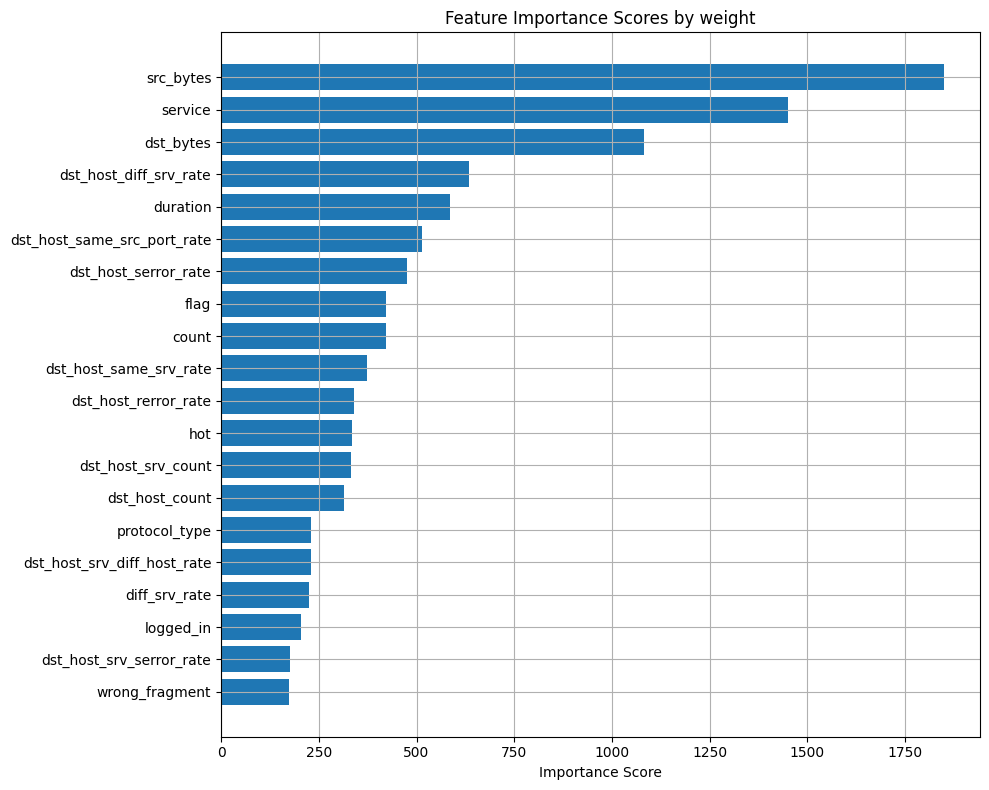


 Feature Importance Scores (weight):
                    feature  importance
                  src_bytes      1849.0
                    service      1449.0
                  dst_bytes      1081.0
     dst_host_diff_srv_rate       634.0
                   duration       586.0
dst_host_same_src_port_rate       515.0
       dst_host_serror_rate       476.0
                       flag       422.0
                      count       421.0
     dst_host_same_srv_rate       373.0
       dst_host_rerror_rate       340.0
                        hot       334.0
         dst_host_srv_count       333.0
             dst_host_count       314.0
              protocol_type       231.0
dst_host_srv_diff_host_rate       229.0
              diff_srv_rate       226.0
                  logged_in       205.0
   dst_host_srv_serror_rate       177.0
             wrong_fragment       173.0
                  srv_count       150.0
            num_compromised       137.0
              same_srv_rate       118.0
  

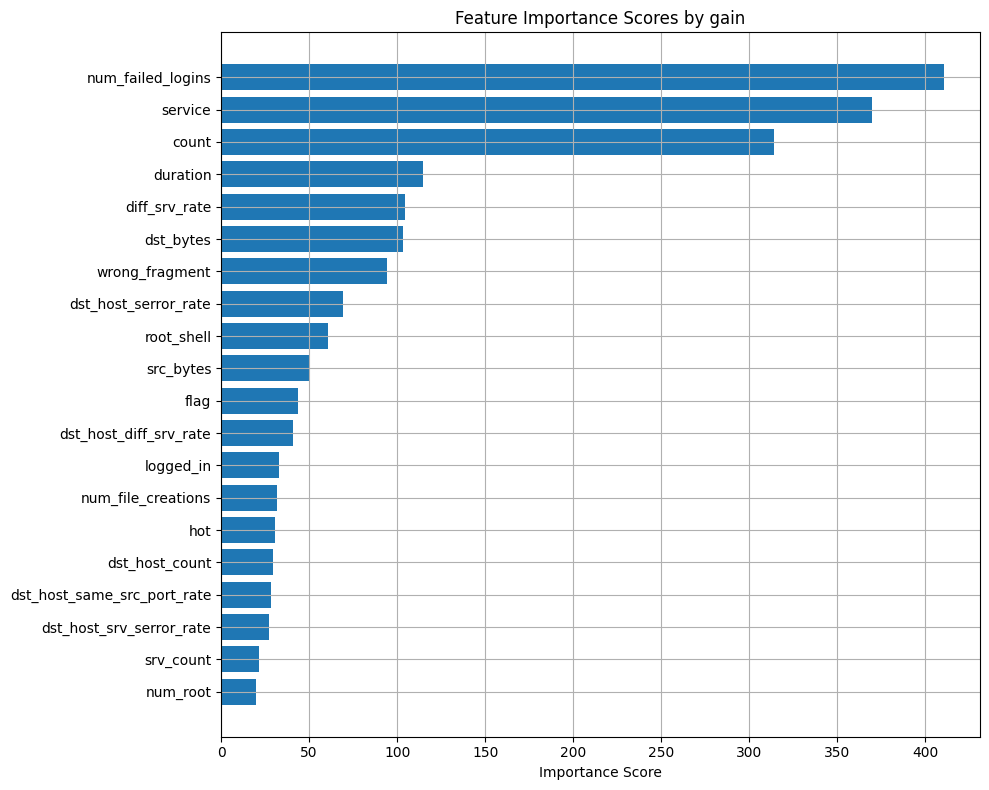


 Feature Importance Scores (gain):
                    feature  importance
          num_failed_logins  410.518188
                    service  369.549683
                      count  314.311401
                   duration  114.738907
              diff_srv_rate  104.311317
                  dst_bytes  103.310516
             wrong_fragment   94.127182
       dst_host_serror_rate   69.034866
                 root_shell   60.456028
                  src_bytes   50.732288
                       flag   43.740871
     dst_host_diff_srv_rate   40.637138
                  logged_in   32.639702
         num_file_creations   31.750000
                        hot   30.405081
             dst_host_count   29.364717
dst_host_same_src_port_rate   28.359575
   dst_host_srv_serror_rate   27.104116
                  srv_count   21.565384
                   num_root   20.078104
            num_compromised   19.009300
           num_access_files   18.725285
              protocol_type   17.047268
    

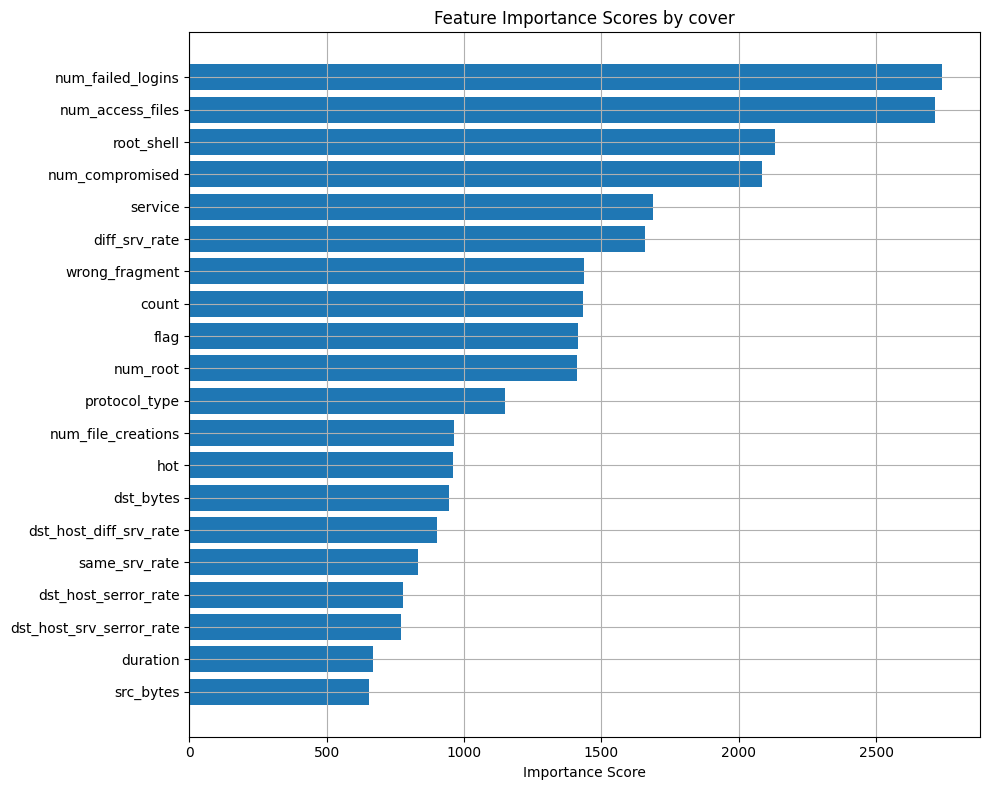


 Feature Importance Scores (cover):
                    feature  importance
          num_failed_logins 2741.633301
           num_access_files 2716.030029
                 root_shell 2133.136719
            num_compromised 2084.015137
                    service 1688.441895
              diff_srv_rate 1657.463379
             wrong_fragment 1436.472778
                      count 1434.112183
                       flag 1414.943970
                   num_root 1411.791138
              protocol_type 1150.714233
         num_file_creations  964.488708
                        hot  958.771240
                  dst_bytes  944.248962
     dst_host_diff_srv_rate  901.036682
              same_srv_rate  833.198120
       dst_host_serror_rate  776.442993
   dst_host_srv_serror_rate  770.861572
                   duration  668.182983
                  src_bytes  652.267700
                  logged_in  573.067139
       dst_host_rerror_rate  438.973022
         dst_host_srv_count  428.209045
   

In [ ]:
# Feature Importance
importance_types = ['weight', 'gain', 'cover']

for imp_type in importance_types:
    scores = model.get_booster().get_score(importance_type=imp_type)
    importance_df = pd.DataFrame({
        'feature': X_train.columns.tolist(),
        'importance': [scores.get(f, 0.0) for f in X_train.columns]
    }).sort_values('importance', ascending=False).reset_index(drop=True)

    top = importance_df.head(20)
    fig, ax = plt.subplots(figsize=(10, 8))
    ax.barh(top['feature'][::-1], top['importance'][::-1])
    ax.set_xlabel('Importance Score')
    ax.set_title(f'Feature Importance Scores by {imp_type}')
    ax.grid(True)
    plt.tight_layout()
    plt.show()

    print(f"\n Feature Importance Scores ({imp_type}):")
    print(importance_df.head(43).to_string(index=False))

In [ ]:
# Load in Test Dataset, Encode it, and separate features and target
# Load test set
df_test = pd.read_csv('/content/drive/MyDrive/xg-ids/5class/datasets/5class_TEST.txt')

# Drop the same zero-variance columns removed from train/validate
if cols_to_drop:
    df_test.drop(columns=cols_to_drop, inplace=True, errors='ignore')
    print(f"Dropped {len(cols_to_drop)} zero-variance column(s) from test set.")

# Cast categorical feature columns to category dtype
for col in categorical_cols:
    df_test[col] = df_test[col].astype('category')

# Encode target using the same LabelEncoder fitted on train set
df_test['class'] = le.transform(df_test['class'])

# Separate features and target
X_test = df_test.drop(columns=['class'])
y_test = df_test['class']

print(f"Test set loaded: {len(df_test)} instances")

Dropped 9 zero-variance column(s) from test set.
Test set loaded: 22544 instances


Accuracy          : 0.8264
F1 (macro)        : 0.6470
F1 (weighted)     : 0.8135
Precision (weighted): 0.8347
Recall (weighted) : 0.8264

Per-class F1:
  DoS: 0.9034
  Normal: 0.8551
  Probe: 0.7743
  R2L: 0.5022
  U2R: 0.2000

Classification Report:
              precision    recall  f1-score   support

         DoS       0.96      0.85      0.90      7458
      Normal       0.77      0.97      0.86      9711
       Probe       0.78      0.77      0.77      2421
         R2L       0.81      0.36      0.50      2754
         U2R       0.43      0.13      0.20       200

    accuracy                           0.83     22544
   macro avg       0.75      0.62      0.65     22544
weighted avg       0.83      0.83      0.81     22544



/usr/local/lib/python3.12/dist-packages/xgboost/core.py:751: UserWarning: [22:46:53] WARNING: /__w/xgboost/xgboost/src/common/error_msg.cc:62: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  return func(**kwargs)


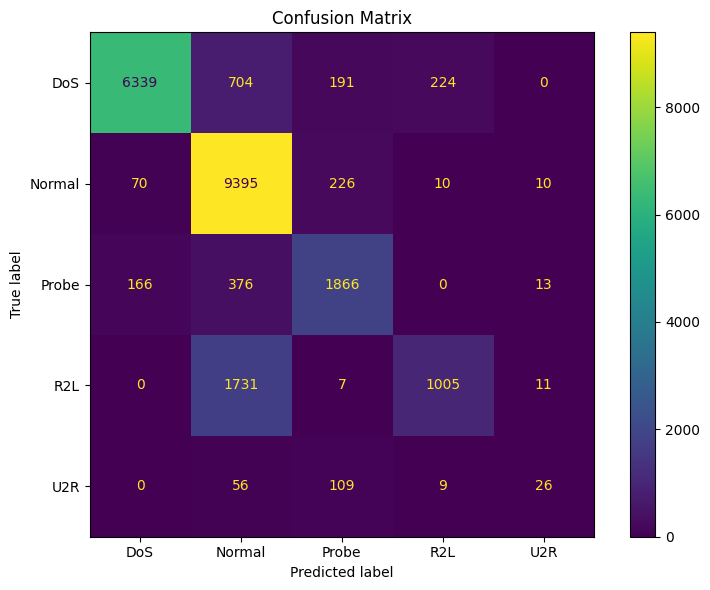

In [ ]:
y_pred = model.predict(X_test)


accuracy  = accuracy_score(y_test, y_pred)
f1_macro  = f1_score(y_test, y_pred, average='macro')
f1_weighted = f1_score(y_test, y_pred, average='weighted')
precision = precision_score(y_test, y_pred, average='weighted')
recall    = recall_score(y_test, y_pred, average='weighted')

print(f"Accuracy          : {accuracy:.4f}")
print(f"F1 (macro)        : {f1_macro:.4f}")
print(f"F1 (weighted)     : {f1_weighted:.4f}")
print(f"Precision (weighted): {precision:.4f}")
print(f"Recall (weighted) : {recall:.4f}")

# F1-Score
f1_per_class = f1_score(y_test, y_pred, average=None)
print(f"\nPer-class F1:")
for cls, score in zip(le.classes_, f1_per_class):
    print(f"  {cls}: {score:.4f}")

# Classification
print(f"\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=le.classes_))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(ax=ax, colorbar=True)
ax.set_title("Confusion Matrix")
plt.tight_layout()
plt.show()